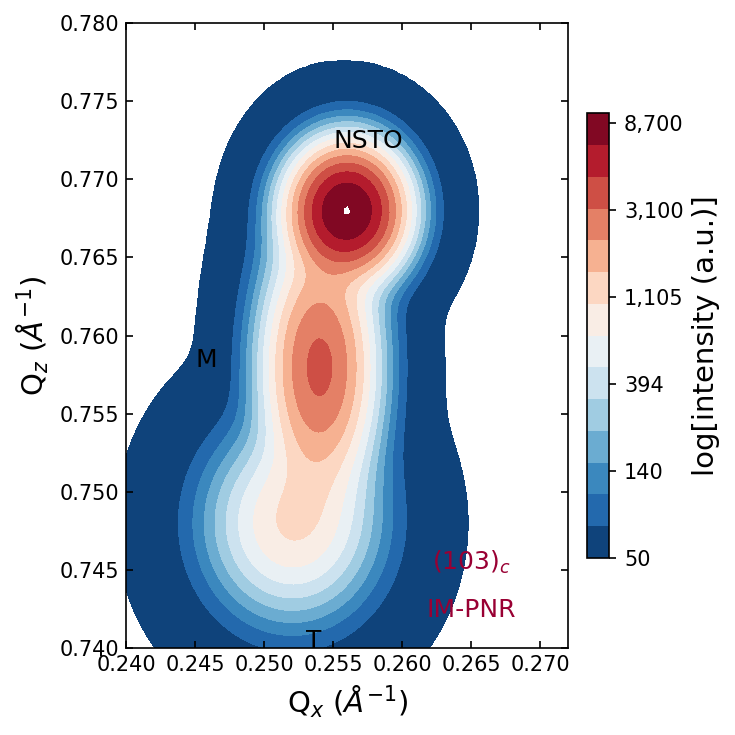

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
qx = np.linspace(0.24, 0.27, 100)
qz = np.linspace(0.74, 0.78, 100)
X, Z = np.meshgrid(qx, qz)

def gaussian_2d(x, z, x0, z0, sx, sz, A):
    return A * np.exp(-((x - x0)**2)/(2*sx**2) - ((z - z0)**2)/(2*sz**2))

# NSTO (Top)
peak_nsto = gaussian_2d(X, Z, 0.256, 0.768, 0.002, 0.002, 10000)

# M (Middle)
peak_m = gaussian_2d(X, Z, 0.254, 0.758, 0.002, 0.004, 3500)

# T (Bottom)
peak_t = gaussian_2d(X, Z, 0.252, 0.748, 0.003, 0.003, 1000)

# Total Intensity
intensity = peak_nsto + peak_m + peak_t + 50 # Base level
log_intensity = np.log10(intensity)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

# Levels based on log scale roughly matching image
levels = np.linspace(1.7, 4.0, 15) # log10(50) approx 1.7, log10(10000) = 4
# Custom diverging colormap to match Blue-White-Red
cmap = plt.cm.RdBu_r
# Plot contourf
cf = ax.contourf(X, Z, log_intensity, levels=levels, cmap=cmap)

# Colorbar
cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('log[intensity (a.u.)]', fontsize=14)
# Fake ticks to match image values
cbar.set_ticks([1.7, 2.15, 2.6, 3.05, 3.5, 3.95])
cbar.set_ticklabels(['50', '140', '394', '1,105', '3,100', '8,700'])

# Labels
ax.text(0.255, 0.772, 'NSTO', fontsize=12)
ax.text(0.245, 0.758, 'M', fontsize=12)
ax.text(0.253, 0.740, 'T', fontsize=12)
ax.text(0.265, 0.745, '(103)$_c$', color='#990033', ha='center', fontsize=12)
ax.text(0.265, 0.742, 'IM-PNR', color='#990033', ha='center', fontsize=12)

# Styling
ax.set_xlabel(r'Q$_x$ ($\AA^{-1}$)', fontsize=14)
ax.set_ylabel(r'Q$_z$ ($\AA^{-1}$)', fontsize=14)
ax.set_xlim(0.24, 0.272)
ax.set_ylim(0.74, 0.78)
ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()
